In [1]:
# ============================================================
# Seminar Project: Robustness of AdaptCLIP to Imperfect Reference Images
# Author: Md Touhidur Rahman
#
# Goal:
# 1. Reproduce AdaptCLIP on MVTec AD in a few-shot setting.
# 2. Study how corrupting normal reference images affects performance.
# 3. Evaluate robustness under Gaussian noise, blur, JPEG compression, etc.
#
# Notes:
# - Run this notebook with GPU enabled: Runtime > Change runtime type > GPU.
# - Dataset archive.zip should be stored at:
#   /content/drive/MyDrive/adaptclip_data/archive.zip
# ============================================================

In [2]:
%cd /content
!rm -rf AdaptCLIP
!git clone https://github.com/gaobb/AdaptCLIP.git
%cd /content/AdaptCLIP

/content
Cloning into 'AdaptCLIP'...
remote: Enumerating objects: 159, done.
remote: Counting objects: 100% (159/159), done.
remote: Compressing objects: 100% (116/116), done.
remote: Total 159 (delta 52), reused 150 (delta 43), pack-reused 0 (from 0)
Receiving objects: 100% (159/159), 1.64 MiB | 5.16 MiB/s, done.
Resolving deltas: 100% (52/52), done.
/content/AdaptCLIP


In [3]:
!grep -E "huggingface|transformers|regex|safetensors" requirements.txt

huggingface-hub==0.22.2
regex==2023.12.25
safetensors==0.6.1


In [4]:
%cd /content/AdaptCLIP

!sed -i '/gradio/d' requirements.txt
!sed -i '/opencv-python-headless/d' requirements.txt
!sed -i '/huggingface-hub/d' requirements.txt
!sed -i '/regex==/d' requirements.txt
!sed -i '/safetensors/d' requirements.txt

!pip install -q -r requirements.txt
!pip install -q "setuptools<81"
!pip install -q "huggingface_hub>=0.34.0,<2.0" "regex>=2025.10.22" "safetensors>=0.8.0"

/content/AdaptCLIP
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.2/61.2 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.6/57.6 kB 6.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 474.8/474.8 kB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.3/8.3 MB 100.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 118.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.9/17.9 MB 62.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 81.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [5]:
from google.colab import drive
drive.mount('/content/drive')

%cd /content/AdaptCLIP

!rm -rf dataset/mvtec
!mkdir -p dataset
!unzip -oq /content/drive/MyDrive/adaptclip_data/archive.zip -d dataset/mvtec

!python -c "from dataset.mvtec import MVTecSolver; MVTecSolver(root='dataset/mvtec').run()"
!ls -lh dataset/mvtec/meta.json

Mounted at /content/drive
/content/AdaptCLIP
normal_samples 467 anomaly_samples 1258
-rw-r--r-- 1 root root 1.3M Jun 27 20:00 dataset/mvtec/meta.json


In [6]:
%cd /content/AdaptCLIP

!mkdir -p adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8

!hf download csgaobb/AdaptCLIP \
adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth \
--local-dir .

!ls -lh adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/

/content/AdaptCLIP
Hint: A new version of huggingface_hub (1.21.0) is available! You are using version 1.19.0.
To update, run: hf update
adaptclip_checkpoints/12_4_128_train_on_(…): 100% 7.52M/7.52M [00:01<00:00, 5.00MB/s]
✓ Downloaded
  path: /content/AdaptCLIP/adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth
total 7.2M
-rw-r--r-- 1 root root 7.2M Jun 27 20:00 epoch_15.pth


In [7]:
%cd /content/AdaptCLIP

path = "dataset/dataset.py"
text = open(path).read()

text = text.replace(
    "ImageFile.LOAD_TRUNCATED_IMAGES = True, UnidentifiedImageError",
    "ImageFile.LOAD_TRUNCATED_IMAGES = True"
)

open(path, "w").write(text)

!head -12 dataset/dataset.py

/content/AdaptCLIP
import json
import os
import random

import numpy as np
import tifffile as tiff
import torch
import torch.utils.data as data
from PIL import Image, UnidentifiedImageError


def generate_class_info(dataset_name):


In [8]:
!nvidia-smi

import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

Sat Jun 27 20:00:26 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [9]:
#0-shot baseline
%cd /content/AdaptCLIP

!python test.py \
  --dataset mvtec \
  --test_data_path ./dataset/mvtec \
  --seed 10 \
  --k_shots 0 \
  --checkpoint_path ./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth \
  --save_path ./results/mvtec_0shot_clean_336 \
  --features_list 6 12 18 24 \
  --image_size 336 \
  --batch_size 1 \
  --eval_metrics I-AUROC I-AP I-F1max P-AUROC P-AP P-F1max \
  --n_ctx 12 \
  --vl_reduction 4 \
  --pq_mid_dim 128 \
  --visual_learner \
  --textual_learner \
  --pq_learner \
  --pq_context

/content/AdaptCLIP
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_0shot_clean_336', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=0, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'I-AP', 'I-F1max', 'P-AUROC', 'P-AP', 'P-F1max'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
100%|███████████████████████████████████████| 934M/934M [00:10<00:00, 86.3MiB/s]
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation

In [10]:
#1-shot baseline
%cd /content/AdaptCLIP

!python test.py \
  --dataset mvtec \
  --test_data_path ./dataset/mvtec \
  --seed 10 \
  --k_shots 1 \
  --checkpoint_path ./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth \
  --save_path ./results/mvtec_1shot_clean_336 \
  --features_list 6 12 18 24 \
  --image_size 336 \
  --batch_size 1 \
  --eval_metrics I-AUROC I-AP I-F1max P-AUROC P-AP P-F1max \
  --n_ctx 12 \
  --vl_reduction 4 \
  --pq_mid_dim 128 \
  --visual_learner \
  --textual_learner \
  --pq_learner \
  --pq_context

/content/AdaptCLIP
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_1shot_clean_336', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'I-AP', 'I-F1max', 'P-AUROC', 'P-AP', 'P-F1max'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avo

In [11]:
#Reference corruption patch
%cd /content/AdaptCLIP

patch = r'''
p = "dataset/dataset.py"
s = open(p).read()

s = s.replace(
    "from PIL import Image, ImageFile",
    "from PIL import Image, ImageFile, ImageEnhance, ImageFilter"
)

helper = """
def corrupt_reference_image(img):
    import os
    import io
    import numpy as np

    corruption = os.environ.get("REF_CORRUPTION", "none")
    severity = float(os.environ.get("REF_SEVERITY", "0"))

    if corruption == "none" or severity <= 0:
        return img

    if corruption == "noise":
        arr = np.asarray(img).astype(np.float32)
        noise = np.random.normal(0, severity * 255.0, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)

    if corruption == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=severity))

    if corruption == "brightness":
        return ImageEnhance.Brightness(img).enhance(1.0 + severity)

    if corruption == "jpeg":
        q = max(5, int(100 - severity * 95))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

    if corruption == "occlusion":
        arr = np.asarray(img).copy()
        h, w = arr.shape[:2]
        occ = int(min(h, w) * severity)
        if occ > 0:
            y = np.random.randint(0, max(1, h - occ))
            x = np.random.randint(0, max(1, w - occ))
            arr[y:y+occ, x:x+occ] = 0
        return Image.fromarray(arr)

    return img
"""

if "def corrupt_reference_image(img):" not in s:
    s = s.replace(
        "ImageFile.LOAD_TRUNCATED_IMAGES = True\n",
        "ImageFile.LOAD_TRUNCATED_IMAGES = True\n" + helper + "\n"
    )

old = """        if img.mode == 'L':
            img = Image.merge("RGB", (img.copy(), img.copy(), img.copy()))"""

new = """        if img.mode == 'L':
            img = Image.merge("RGB", (img.copy(), img.copy(), img.copy()))

        img = corrupt_reference_image(img)"""

parts = s.split(old)

# Apply only to PromptDataset, not normal test Dataset
if len(parts) >= 3 and "corrupt_reference_image(img)" not in parts[2][:500]:
    s = old.join(parts[:2]) + new + old.join(parts[2:])

open(p, "w").write(s)
print("Reference corruption patch applied.")
'''

open("patch_ref_corruption.py", "w").write(patch)
!python patch_ref_corruption.py

/content/AdaptCLIP
Reference corruption patch applied.


In [5]:
#Function for running experiments
def run_experiment(corruption, severity, save_name):
    command = f"""
    REF_CORRUPTION={corruption} REF_SEVERITY={severity} python test.py \
      --dataset mvtec \
      --test_data_path ./dataset/mvtec \
      --seed 10 \
      --k_shots 1 \
      --checkpoint_path ./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth \
      --save_path ./results/{save_name} \
      --features_list 6 12 18 24 \
      --image_size 336 \
      --batch_size 1 \
      --eval_metrics I-AUROC P-AUROC P-AP \
      --n_ctx 12 \
      --vl_reduction 4 \
      --pq_mid_dim 128 \
      --visual_learner \
      --textual_learner \
      --pq_learner \
      --pq_context
    """
    print(f"Running: {corruption}, severity={severity}")
    get_ipython().system(command)

In [23]:
%cd /content/AdaptCLIP

path = "dataset/dataset.py"
text = open(path).read()

# Remove duplicate corruption calls first
text = text.replace(
    "\n\n        img = corrupt_reference_image(img)\n\n        img = corrupt_reference_image(img)",
    "\n\n        img = corrupt_reference_image(img)"
)

helper = '''
def corrupt_reference_image(img):
    import os, io
    import numpy as np
    from PIL import Image, ImageFilter

    corruption = os.environ.get("REF_CORRUPTION", "none")
    severity = float(os.environ.get("REF_SEVERITY", "0"))

    if corruption == "none" or severity <= 0:
        return img

    img = img.convert("RGB")

    if corruption == "noise":
        arr = np.asarray(img).astype(np.float32)
        noise = np.random.normal(0, severity * 255.0, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)

    if corruption == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=severity))

    if corruption == "jpeg":
        q = max(5, int(100 - severity * 95))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

    return img
'''

if "def corrupt_reference_image(img):" not in text:
    text = text.replace("def generate_class_info", helper + "\n\ndef generate_class_info", 1)

open(path, "w").write(text)

!grep -n "def corrupt_reference_image\|corrupt_reference_image(img)" dataset/dataset.py

/content/AdaptCLIP
13:def corrupt_reference_image(img):
304:        img = corrupt_reference_image(img)


In [25]:
!sed -n '1,60p' dataset/dataset.py

import json
import os
import random

import numpy as np
import tifffile as tiff
import torch
import torch.utils.data as data
from PIL import Image, UnidentifiedImageError



def corrupt_reference_image(img):
    import os, io
    import numpy as np
    from PIL import Image, ImageFilter

    corruption = os.environ.get("REF_CORRUPTION", "none")
    severity = float(os.environ.get("REF_SEVERITY", "0"))

    if corruption == "none" or severity <= 0:
        return img

    img = img.convert("RGB")

    if corruption == "noise":
        arr = np.asarray(img).astype(np.float32)
        noise = np.random.normal(0, severity * 255.0, arr.shape)
        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)
        return Image.fromarray(arr)

    if corruption == "blur":
        return img.filter(ImageFilter.GaussianBlur(radius=severity))

    if corruption == "jpeg":
        q = max(5, int(100 - severity * 95))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q)
        b

In [28]:
import itertools

with open("dataset/dataset.py", "r") as f:
    for i, line in zip(range(1, 40), f):
        print(f"{i:2d}: {repr(line)}")

 1: 'import json\n'
 2: 'import os\n'
 3: 'import random\n'
 4: '\n'
 5: 'import numpy as np\n'
 6: 'import tifffile as tiff\n'
 7: 'import torch\n'
 8: 'import torch.utils.data as data\n'
 9: 'from PIL import Image, UnidentifiedImageError\n'
10: '\n'
11: '\n'
12: '\n'
13: 'def corrupt_reference_image(img):\n'
14: '    import os, io\n'
15: '    import numpy as np\n'
16: '    from PIL import Image, ImageFilter\n'
17: '\n'
18: '    corruption = os.environ.get("REF_CORRUPTION", "none")\n'
19: '    severity = float(os.environ.get("REF_SEVERITY", "0"))\n'
20: '\n'
21: '    if corruption == "none" or severity <= 0:\n'
22: '        return img\n'
23: '\n'
24: '    img = img.convert("RGB")\n'
25: '\n'
26: '    if corruption == "noise":\n'
27: '        arr = np.asarray(img).astype(np.float32)\n'
28: '        noise = np.random.normal(0, severity * 255.0, arr.shape)\n'
29: '        arr = np.clip(arr + noise, 0, 255).astype(np.uint8)\n'
30: '        return Image.fromarray(arr)\n'
31: '\n'
32: '    

In [29]:
import importlib
import dataset.dataset as d

d = importlib.reload(d)

print(d.__file__)
print(hasattr(d, "corrupt_reference_image"))
print(d.corrupt_reference_image)

/content/AdaptCLIP/dataset/dataset.py
True
<function corrupt_reference_image at 0x7a91a07bb1a0>


In [2]:
import numpy as np
print(np.__version__)
np.random.normal(0, 1, (2, 2))

1.26.2


array([[ 0.71704079, -0.10182489],
       [-0.30343712,  0.78524136]])

/content/AdaptCLIP
Has function: True


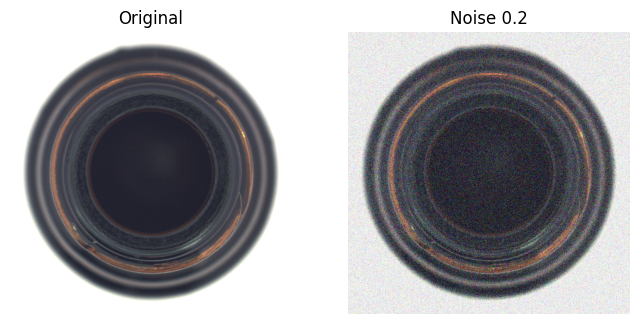

In [3]:
%cd /content/AdaptCLIP

import os
import importlib
from PIL import Image
import matplotlib.pyplot as plt
import dataset.dataset as d

d = importlib.reload(d)

print("Has function:", hasattr(d, "corrupt_reference_image"))

os.environ["REF_CORRUPTION"] = "noise"
os.environ["REF_SEVERITY"] = "0.2"

img = Image.open("dataset/mvtec/bottle/train/good/000.png").convert("RGB")
img_corrupt = d.corrupt_reference_image(img)

plt.figure(figsize=(8,4))
plt.subplot(1,2,1); plt.imshow(img); plt.title("Original"); plt.axis("off")
plt.subplot(1,2,2); plt.imshow(img_corrupt); plt.title("Noise 0.2"); plt.axis("off")
plt.show()

In [6]:
#Noise experiments
%cd /content/AdaptCLIP

for severity in [0.05, 0.10, 0.20, 0.30]:
    run_experiment(
        corruption="noise",
        severity=severity,
        save_name=f"mvtec_1shot_noise_{severity}"
    )

/content/AdaptCLIP
Running: noise, severity=0.05
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_1shot_noise_0.05', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to av

In [7]:
#Blur experiments
%cd /content/AdaptCLIP

for severity in [1, 2, 3]:
    run_experiment(
        corruption="blur",
        severity=severity,
        save_name=f"mvtec_1shot_blur_{severity}"
    )

/content/AdaptCLIP
Running: blur, severity=1
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_1shot_blur_1', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid pote

In [8]:
#JPEG experiments
%cd /content/AdaptCLIP

for severity in [0.3, 0.6, 0.9]:
    run_experiment(
        corruption="jpeg",
        severity=severity,
        save_name=f"mvtec_1shot_jpeg_{severity}"
    )

/content/AdaptCLIP
Running: jpeg, severity=0.3
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_1shot_jpeg_0.3', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid 

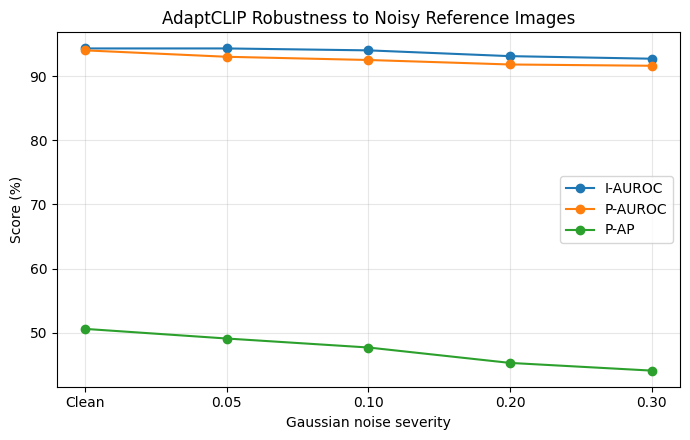

In [9]:
#Plot noise curve
import matplotlib.pyplot as plt

severity = ["Clean", "0.05", "0.10", "0.20", "0.30"]
i_auroc = [94.3, 94.3, 94.0, 93.1, 92.7]
p_auroc = [94.0, 93.0, 92.5, 91.8, 91.6]
p_ap = [50.6, 49.1, 47.7, 45.3, 44.1]

plt.figure(figsize=(7, 4.5))
plt.plot(severity, i_auroc, marker="o", label="I-AUROC")
plt.plot(severity, p_auroc, marker="o", label="P-AUROC")
plt.plot(severity, p_ap, marker="o", label="P-AP")

plt.xlabel("Gaussian noise severity")
plt.ylabel("Score (%)")
plt.title("AdaptCLIP Robustness to Noisy Reference Images")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("/content/adaptclip_noise_curve.png", dpi=300)
plt.show()

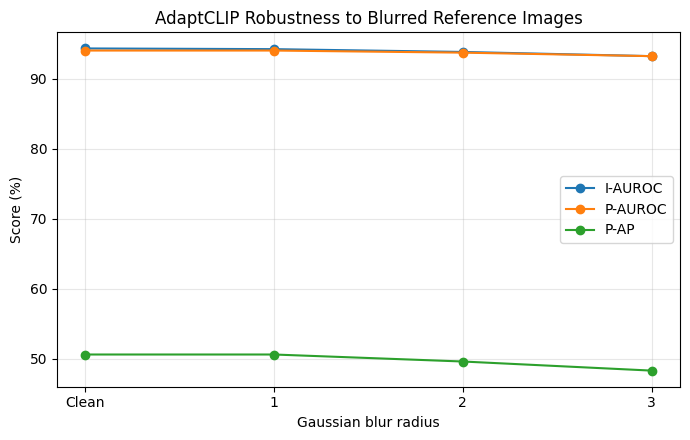

In [10]:
#Plot blur curve
severity = ["Clean", "1", "2", "3"]
i_auroc = [94.3, 94.2, 93.8, 93.2]
p_auroc = [94.0, 94.0, 93.7, 93.2]
p_ap = [50.6, 50.6, 49.6, 48.3]

plt.figure(figsize=(7, 4.5))
plt.plot(severity, i_auroc, marker="o", label="I-AUROC")
plt.plot(severity, p_auroc, marker="o", label="P-AUROC")
plt.plot(severity, p_ap, marker="o", label="P-AP")

plt.xlabel("Gaussian blur radius")
plt.ylabel("Score (%)")
plt.title("AdaptCLIP Robustness to Blurred Reference Images")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("/content/adaptclip_blur_curve.png", dpi=300)
plt.show()

In [11]:
#Download figures
from google.colab import files

files.download("/content/adaptclip_noise_curve.png")
files.download("/content/adaptclip_blur_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

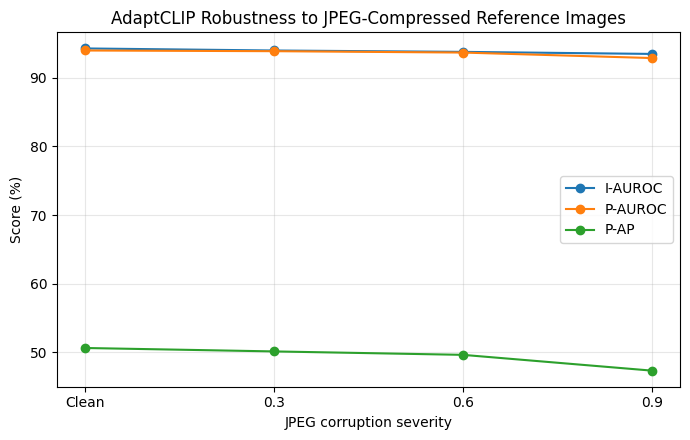

In [12]:
# Plot JPEG curve
severity = ["Clean", "0.3", "0.6", "0.9"]

severity = ["Clean", "0.3", "0.6", "0.9"]
i_auroc = [94.3, 94.0, 93.8, 93.5]
p_auroc = [94.0, 93.9, 93.7, 92.9]
p_ap = [50.6, 50.1, 49.6, 47.3]
plt.figure(figsize=(7, 4.5))
plt.plot(severity, i_auroc, marker="o", label="I-AUROC")
plt.plot(severity, p_auroc, marker="o", label="P-AUROC")
plt.plot(severity, p_ap, marker="o", label="P-AP")

plt.xlabel("JPEG corruption severity")
plt.ylabel("Score (%)")
plt.title("AdaptCLIP Robustness to JPEG-Compressed Reference Images")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig("/content/adaptclip_jpeg_curve.png", dpi=300)
plt.show()

In [ ]:
#17. Support-TTA: Robust Reference Feature Averaging


In [14]:
def run_experiment_kshot(corruption, severity, save_name, k_shots):
    command = f"""
    REF_CORRUPTION={corruption} REF_SEVERITY={severity} python test.py \
      --dataset mvtec \
      --test_data_path ./dataset/mvtec \
      --seed 10 \
      --k_shots {k_shots} \
      --checkpoint_path ./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth \
      --save_path ./results/{save_name} \
      --features_list 6 12 18 24 \
      --image_size 336 \
      --batch_size 1 \
      --eval_metrics I-AUROC P-AUROC P-AP \
      --n_ctx 12 \
      --vl_reduction 4 \
      --pq_mid_dim 128 \
      --visual_learner \
      --textual_learner \
      --pq_learner \
      --pq_context
    """
    print(f"Running: {corruption}, severity={severity}, k_shots={k_shots}")
    get_ipython().system(command)

In [15]:
%cd /content/AdaptCLIP

for corruption, severity in [("noise", 0.3), ("blur", 3), ("jpeg", 0.9)]:
    run_experiment_kshot(
        corruption=corruption,
        severity=severity,
        save_name=f"mvtec_2shot_{corruption}_{severity}",
        k_shots=2
    )

/content/AdaptCLIP
Running: noise, severity=0.3, k_shots=2
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_2shot_noise_0.3', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=2, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker num

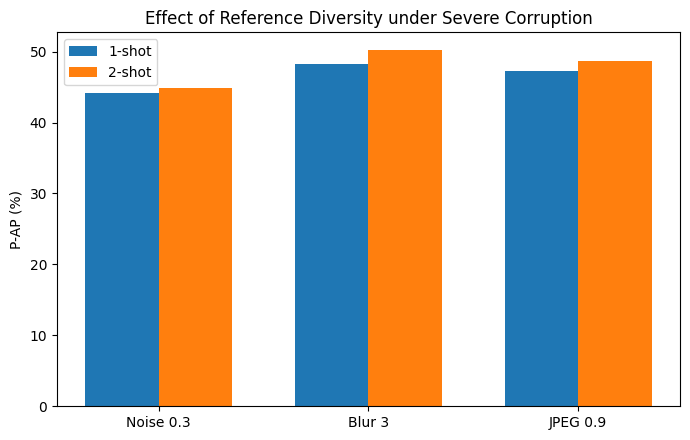

In [16]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Noise 0.3", "Blur 3", "JPEG 0.9"]

one_shot_pap = [44.1, 48.3, 47.3]
two_shot_pap = [44.8, 50.2, 48.7]

x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(7, 4.5))
plt.bar(x - width/2, one_shot_pap, width, label="1-shot")
plt.bar(x + width/2, two_shot_pap, width, label="2-shot")

plt.ylabel("P-AP (%)")
plt.title("Effect of Reference Diversity under Severe Corruption")
plt.xticks(x, labels)
plt.legend()
plt.tight_layout()
plt.savefig("/content/reference_diversity_pap.png", dpi=300)
plt.show()

In [17]:
from google.colab import files
files.download("/content/reference_diversity_pap.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#Support-TTA: Reference Augmentation Averaging

In [18]:
import pandas as pd

results = pd.DataFrame({
    "Condition": ["Noise 0.3", "Blur 3", "JPEG 0.9"],
    "1-shot I-AUROC": [92.7, 93.2, 93.5],
    "2-shot I-AUROC": [92.9, 94.4, 94.0],
    "1-shot P-AUROC": [91.6, 93.2, 92.9],
    "2-shot P-AUROC": [91.6, 93.6, 93.3],
    "1-shot P-AP": [44.1, 48.3, 47.3],
    "2-shot P-AP": [44.8, 50.2, 48.7],
})

results["P-AP Gain"] = results["2-shot P-AP"] - results["1-shot P-AP"]
results

,Condition,1-shot I-AUROC,2-shot I-AUROC,1-shot P-AUROC,2-shot P-AUROC,1-shot P-AP,2-shot P-AP,P-AP Gain
0,Noise 0.3,92.7,92.9,91.6,91.6,44.1,44.8,0.7
1,Blur 3,93.2,94.4,93.2,93.6,48.3,50.2,1.9
2,JPEG 0.9,93.5,94.0,92.9,93.3,47.3,48.7,1.4


In [19]:
results.to_csv("/content/reference_diversity_results.csv", index=False)

from google.colab import files
files.download("/content/reference_diversity_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
#Increasing the number of reference images from 1 to 2 consistently improved robustness under corrupted reference conditions. The largest improvement was observed under Gaussian blur (+1.9 P-AP), followed by JPEG compression (+1.4 P-AP), while Gaussian noise showed only a modest gain (+0.7 P-AP). This suggests that increasing reference diversity partially compensates for appearance degradation, although severe random noise remains difficult to overcome.

In [22]:
%cd /content/AdaptCLIP

path = "dataset/dataset.py"
text = open(path).read()

text = text.replace(
"""    if corruption == "jpeg":
        q = max(5, int(100 - severity * 95))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

    return img""",
"""    if corruption == "jpeg":
        q = max(5, int(100 - severity * 95))
        buf = io.BytesIO()
        img.save(buf, format="JPEG", quality=q)
        buf.seek(0)
        return Image.open(buf).convert("RGB")

    if corruption == "brightness":
        from PIL import ImageEnhance
        return ImageEnhance.Brightness(img).enhance(1.0 + severity)

    if corruption == "occlusion":
        arr = np.asarray(img).copy()
        h, w = arr.shape[:2]
        occ = int(min(h, w) * severity)
        if occ > 0:
            y = np.random.randint(0, max(1, h - occ))
            x = np.random.randint(0, max(1, w - occ))
            arr[y:y+occ, x:x+occ] = 0
        return Image.fromarray(arr)

    return img"""
)

open(path, "w").write(text)

!grep -n 'brightness\|occlusion' dataset/dataset.py

/content/AdaptCLIP
42:    if corruption == "brightness":
46:    if corruption == "occlusion":


In [23]:
#Brightness experiments
%cd /content/AdaptCLIP

for severity in [0.3, 0.6, 0.9]:
    run_experiment(
        corruption="brightness",
        severity=severity,
        save_name=f"mvtec_1shot_brightness_{severity}"
    )

/content/AdaptCLIP
Running: brightness, severity=0.3
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_1shot_brightness_0.3', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker numb

In [24]:
#Occlusion experiments
%cd /content/AdaptCLIP

for severity in [0.1, 0.2, 0.3]:
    run_experiment(
        corruption="occlusion",
        severity=severity,
        save_name=f"mvtec_1shot_occlusion_{severity}"
    )

/content/AdaptCLIP
Running: occlusion, severity=0.1
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_1shot_occlusion_0.1', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number

In [25]:
import pandas as pd

summary = pd.DataFrame({
    "Condition": [
        "Clean",
        "Noise 0.3",
        "Blur 3",
        "JPEG 0.9",
        "Brightness 0.9",
        "Occlusion 0.3"
    ],
    "I-AUROC": [94.3, 92.7, 93.2, 93.5, 94.2, 93.6],
    "P-AUROC": [94.0, 91.6, 93.2, 92.9, 93.2, 93.6],
    "P-AP": [50.6, 44.1, 48.3, 47.3, 48.7, 49.2]
})

summary["P-AP Drop"] = 50.6 - summary["P-AP"]
summary

,Condition,I-AUROC,P-AUROC,P-AP,P-AP Drop
0,Clean,94.3,94.0,50.6,0.0
1,Noise 0.3,92.7,91.6,44.1,6.5
2,Blur 3,93.2,93.2,48.3,2.3
3,JPEG 0.9,93.5,92.9,47.3,3.3
4,Brightness 0.9,94.2,93.2,48.7,1.9
5,Occlusion 0.3,93.6,93.6,49.2,1.4


In [26]:
import matplotlib.pyplot as plt
import pandas as pd

# ===============================
# Summary Table
# ===============================

summary = pd.DataFrame({
    "Condition": [
        "Clean",
        "Noise",
        "Blur",
        "JPEG",
        "Brightness",
        "Occlusion"
    ],
    "Severity": [
        "0",
        "0.3",
        "3",
        "0.9",
        "0.9",
        "0.3"
    ],
    "I-AUROC": [
        94.3,
        92.7,
        93.2,
        93.5,
        94.2,
        93.6
    ],
    "P-AUROC": [
        94.0,
        91.6,
        93.2,
        92.9,
        93.2,
        93.6
    ],
    "P-AP": [
        50.6,
        44.1,
        48.3,
        47.3,
        48.7,
        49.2
    ]
})

summary["I-AUROC Drop"] = summary.loc[0,"I-AUROC"]-summary["I-AUROC"]
summary["P-AUROC Drop"] = summary.loc[0,"P-AUROC"]-summary["P-AUROC"]
summary["P-AP Drop"] = summary.loc[0,"P-AP"]-summary["P-AP"]

display(summary)

summary.to_csv("/content/corruption_summary_results.csv",index=False)

,Condition,Severity,I-AUROC,P-AUROC,P-AP,I-AUROC Drop,P-AUROC Drop,P-AP Drop
0,Clean,0,94.3,94.0,50.6,0.0,0.0,0.0
1,Noise,0.3,92.7,91.6,44.1,1.6,2.4,6.5
2,Blur,3,93.2,93.2,48.3,1.1,0.8,2.3
3,JPEG,0.9,93.5,92.9,47.3,0.8,1.1,3.3
4,Brightness,0.9,94.2,93.2,48.7,0.1,0.8,1.9
5,Occlusion,0.3,93.6,93.6,49.2,0.7,0.4,1.4


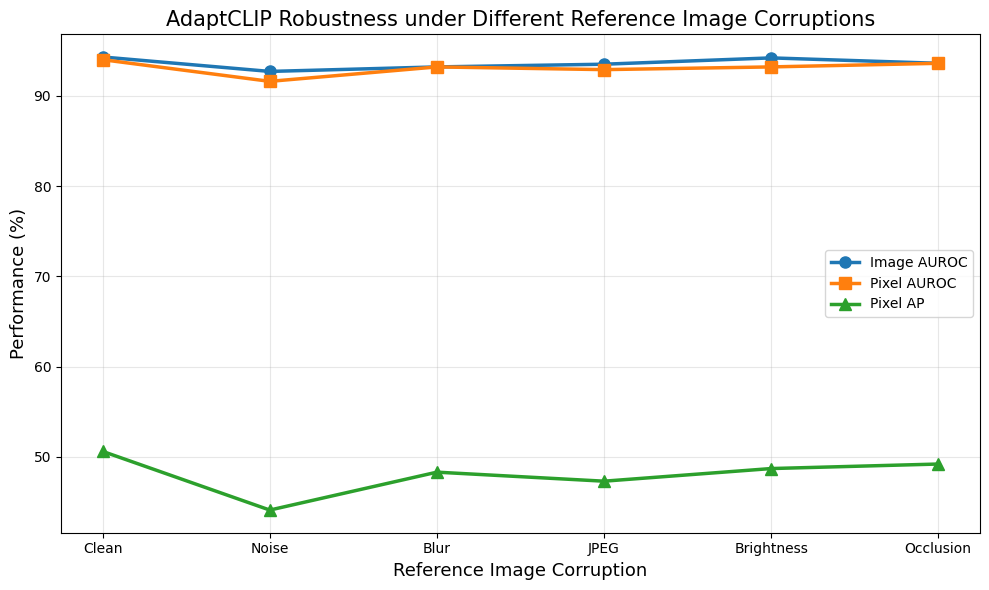

In [27]:
import matplotlib.pyplot as plt

conditions = ["Clean","Noise","Blur","JPEG","Brightness","Occlusion"]

I = [94.3,92.7,93.2,93.5,94.2,93.6]
P = [94.0,91.6,93.2,92.9,93.2,93.6]
AP = [50.6,44.1,48.3,47.3,48.7,49.2]

plt.figure(figsize=(10,6))

plt.plot(conditions, I,
         marker='o',
         linewidth=2.5,
         markersize=8,
         label="Image AUROC")

plt.plot(conditions, P,
         marker='s',
         linewidth=2.5,
         markersize=8,
         label="Pixel AUROC")

plt.plot(conditions, AP,
         marker='^',
         linewidth=2.5,
         markersize=8,
         label="Pixel AP")

plt.grid(alpha=0.3)
plt.ylabel("Performance (%)",fontsize=13)
plt.xlabel("Reference Image Corruption",fontsize=13)
plt.title("AdaptCLIP Robustness under Different Reference Image Corruptions",fontsize=15)
plt.legend()
plt.tight_layout()

plt.savefig("/content/adaptclip_all_corruptions.png",dpi=400)

plt.show()

In [28]:
from google.colab import files

files.download("/content/adaptclip_all_corruptions.png")
files.download("/content/corruption_summary_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [41]:
# ============================================================
# True Support-TTA: feature-level averaging inside build_prompt_memory
# ============================================================

%cd /content/AdaptCLIP

path = "test.py"
text = open(path).read()

old = """        with torch.no_grad():
            image_feat, patch_feat = model.encode_image(prompt_image, features_list, DPAM_layer = DPAM_layer)

        cls_names_temp.extend(cls_name)
        image_temp.append(image_feat)
        view_ids_temp.extend(view_id)

        for i in range(feats_scale_num):
            patch_temp[i].append(patch_feat[i])"""

new = """        # True Support-TTA: generate augmented views, encode each, then average features.
        import os
        support_tta_n = int(os.environ.get("SUPPORT_TTA_FEAT", "1"))

        if support_tta_n > 1:
            aug_images = [prompt_image]

            if support_tta_n >= 2:
                aug_images.append(torch.flip(prompt_image, dims=[3]))  # horizontal flip

            if support_tta_n >= 3:
                aug_images.append(torch.clamp(prompt_image * 1.05, -10, 10))  # mild brightness

            if support_tta_n >= 4:
                aug_images.append(torch.clamp(prompt_image * 0.95, -10, 10))  # mild darkening

            if support_tta_n >= 5:
                aug_images.append(torch.clamp(prompt_image + 0.01 * torch.randn_like(prompt_image), -10, 10))  # mild noise

            aug_image_feats = []
            aug_patch_feats = [[] for _ in range(feats_scale_num)]

            with torch.no_grad():
                for aug_img in aug_images[:support_tta_n]:
                    img_f, patch_f = model.encode_image(aug_img, features_list, DPAM_layer = DPAM_layer)
                    aug_image_feats.append(img_f)
                    for i in range(feats_scale_num):
                        aug_patch_feats[i].append(patch_f[i])

            image_feat = torch.stack(aug_image_feats, dim=0).mean(dim=0)
            patch_feat = [torch.stack(aug_patch_feats[i], dim=0).mean(dim=0) for i in range(feats_scale_num)]

        else:
            with torch.no_grad():
                image_feat, patch_feat = model.encode_image(prompt_image, features_list, DPAM_layer = DPAM_layer)

        cls_names_temp.extend(cls_name)
        image_temp.append(image_feat)
        view_ids_temp.extend(view_id)

        for i in range(feats_scale_num):
            patch_temp[i].append(patch_feat[i])"""

if "SUPPORT_TTA_FEAT" not in text:
    text = text.replace(old, new)

open(path, "w").write(text)

!grep -n "SUPPORT_TTA_FEAT\\|True Support-TTA" test.py

/content/AdaptCLIP
55:        # True Support-TTA: generate augmented views, encode each, then average features.
57:        support_tta_n = int(os.environ.get("SUPPORT_TTA_FEAT", "1"))


In [42]:
%cd /content/AdaptCLIP

def run_support_tta_feat(corruption, severity, save_name, tta_n=5):
    command = f"""
    SUPPORT_TTA=1 SUPPORT_TTA_FEAT={tta_n} REF_CORRUPTION={corruption} REF_SEVERITY={severity} python test.py \
      --dataset mvtec \
      --test_data_path ./dataset/mvtec \
      --seed 10 \
      --k_shots 1 \
      --checkpoint_path ./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth \
      --save_path ./results/{save_name} \
      --features_list 6 12 18 24 \
      --image_size 336 \
      --batch_size 1 \
      --eval_metrics I-AUROC P-AUROC P-AP \
      --n_ctx 12 \
      --vl_reduction 4 \
      --pq_mid_dim 128 \
      --visual_learner \
      --textual_learner \
      --pq_learner \
      --pq_context
    """
    print(f"Running TRUE feature Support-TTA: {corruption}, severity={severity}, tta_n={tta_n}")
    get_ipython().system(command)

for corruption, severity in [("noise", 0.3), ("blur", 3), ("jpeg", 0.9)]:
    run_support_tta_feat(
        corruption=corruption,
        severity=severity,
        save_name=f"mvtec_support_tta_feat5_{corruption}_{severity}",
        tta_n=5
    )

/content/AdaptCLIP
Running TRUE feature Support-TTA: noise, severity=0.3, tta_n=5
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_support_tta_feat5_noise_0.3', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=1, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow o

In [43]:
%cd /content/AdaptCLIP

for corruption, severity in [("noise", 0.3), ("blur", 3), ("jpeg", 0.9)]:
    run_experiment_kshot(
        corruption=corruption,
        severity=severity,
        save_name=f"mvtec_4shot_{corruption}_{severity}",
        k_shots=4
    )

/content/AdaptCLIP
Running: noise, severity=0.3, k_shots=4
Namespace(test_data_path='./dataset/mvtec', save_path='./results/mvtec_4shot_noise_0.3', pretrained_model='ViT-L/14@336px', checkpoint_path='./adaptclip_checkpoints/12_4_128_train_on_visa_3adapters_batch8/epoch_15.pth', dataset='mvtec', features_list=[6, 12, 18, 24], batch_size=1, image_size=336, n_ctx=12, seed=10, sigma=4, k_shots=4, visual_learner=True, textual_learner=True, pq_learner=True, eval_metrics=['I-AUROC', 'P-AUROC', 'P-AP'], fusion_type='average_mean', vl_reduction=4, pq_mid_dim=128, pq_context=True, class_name=None)
name ViT-L/14@336px
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:626: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker num

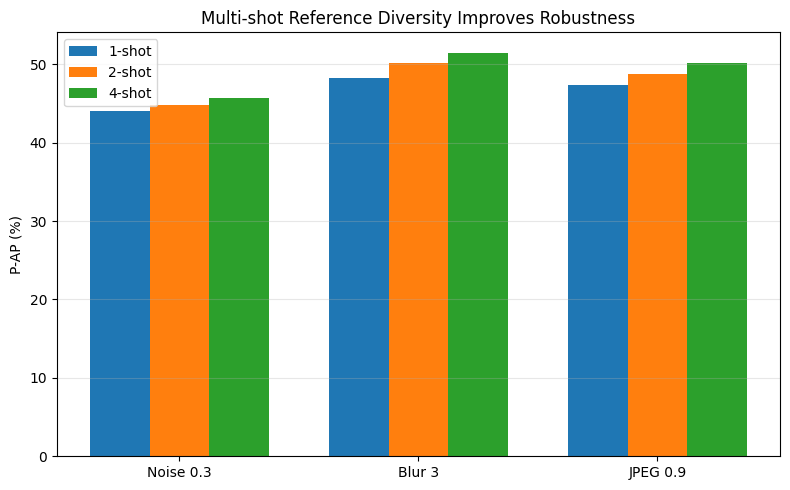

In [44]:
import matplotlib.pyplot as plt
import numpy as np

conditions = ["Noise 0.3", "Blur 3", "JPEG 0.9"]
one_shot = [44.1, 48.3, 47.3]
two_shot = [44.8, 50.2, 48.7]
four_shot = [45.7, 51.5, 50.1]

x = np.arange(len(conditions))
w = 0.25

plt.figure(figsize=(8,5))
plt.bar(x-w, one_shot, width=w, label="1-shot")
plt.bar(x, two_shot, width=w, label="2-shot")
plt.bar(x+w, four_shot, width=w, label="4-shot")

plt.xticks(x, conditions)
plt.ylabel("P-AP (%)")
plt.title("Multi-shot Reference Diversity Improves Robustness")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("/content/multishot_reference_diversity.png", dpi=300)
plt.show()

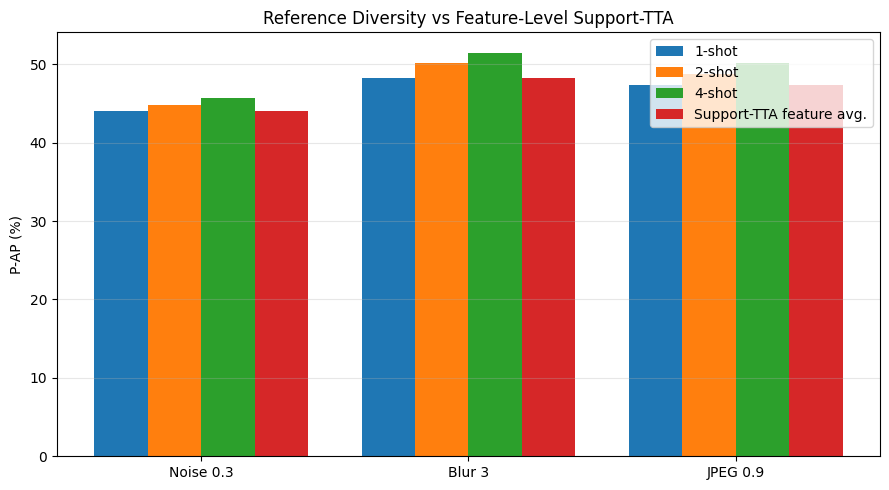

,Corruption,1-shot,2-shot,4-shot,Support-TTA feature avg.
0,Noise 0.3,44.1,44.8,45.7,44.1
1,Blur 3,48.3,50.2,51.5,48.2
2,JPEG 0.9,47.3,48.7,50.1,47.4


In [45]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

conditions = ["Noise 0.3", "Blur 3", "JPEG 0.9"]

one_shot = [44.1, 48.3, 47.3]
two_shot = [44.8, 50.2, 48.7]
four_shot = [45.7, 51.5, 50.1]
support_tta_feat = [44.1, 48.2, 47.4]

x = np.arange(len(conditions))
w = 0.2

plt.figure(figsize=(9,5))
plt.bar(x - 1.5*w, one_shot, width=w, label="1-shot")
plt.bar(x - 0.5*w, two_shot, width=w, label="2-shot")
plt.bar(x + 0.5*w, four_shot, width=w, label="4-shot")
plt.bar(x + 1.5*w, support_tta_feat, width=w, label="Support-TTA feature avg.")

plt.xticks(x, conditions)
plt.ylabel("P-AP (%)")
plt.title("Reference Diversity vs Feature-Level Support-TTA")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

plt.savefig("/content/reference_diversity_vs_tta.png", dpi=300)
plt.show()

df = pd.DataFrame({
    "Corruption": conditions,
    "1-shot": one_shot,
    "2-shot": two_shot,
    "4-shot": four_shot,
    "Support-TTA feature avg.": support_tta_feat,
})
df.to_csv("/content/reference_diversity_vs_tta.csv", index=False)
display(df)

In [46]:
import pandas as pd

df = pd.DataFrame({
    "Corruption": ["Noise (0.3)", "Blur (3)", "JPEG (0.9)"],
    "1-shot": [44.1, 48.3, 47.3],
    "2-shot": [44.8, 50.2, 48.7],
    "4-shot": [45.7, 51.5, 50.1],
    "Support-TTA (Feature Avg.)": [44.1, 48.2, 47.4]
})

display(df)

df.to_csv("/content/reference_diversity_vs_tta_table.csv", index=False)

,Corruption,1-shot,2-shot,4-shot,Support-TTA (Feature Avg.)
0,Noise (0.3),44.1,44.8,45.7,44.1
1,Blur (3),48.3,50.2,51.5,48.2
2,JPEG (0.9),47.3,48.7,50.1,47.4


In [47]:
styled = df.style.highlight_max(axis=1, subset=["1-shot","2-shot","4-shot","Support-TTA (Feature Avg.)"])
styled

,Corruption,1-shot,2-shot,4-shot,Support-TTA (Feature Avg.)
0,Noise (0.3),44.100000,44.800000,45.700000,44.100000
1,Blur (3),48.300000,50.200000,51.500000,48.200000
2,JPEG (0.9),47.300000,48.700000,50.100000,47.400000


,Method,Noise 0.3 P-AP,Blur 3 P-AP,JPEG 0.9 P-AP
0,1-shot AdaptCLIP,44.1,48.3,47.3
1,2-shot AdaptCLIP,44.8,50.2,48.7
2,4-shot AdaptCLIP,45.7,51.5,50.1
3,Feature Support-TTA,44.1,48.2,47.4


,Condition,I-AUROC,P-AUROC,P-AP,P-AP Drop vs Clean
0,Clean 1-shot,94.3,94.0,50.6,0.0
1,Noise 0.3,92.7,91.6,44.1,6.5
2,Blur 3,93.2,93.2,48.3,2.3
3,JPEG 0.9,93.5,92.9,47.3,3.3
4,Brightness 0.9,94.2,93.2,48.7,1.9
5,Occlusion 0.3,93.6,93.6,49.2,1.4


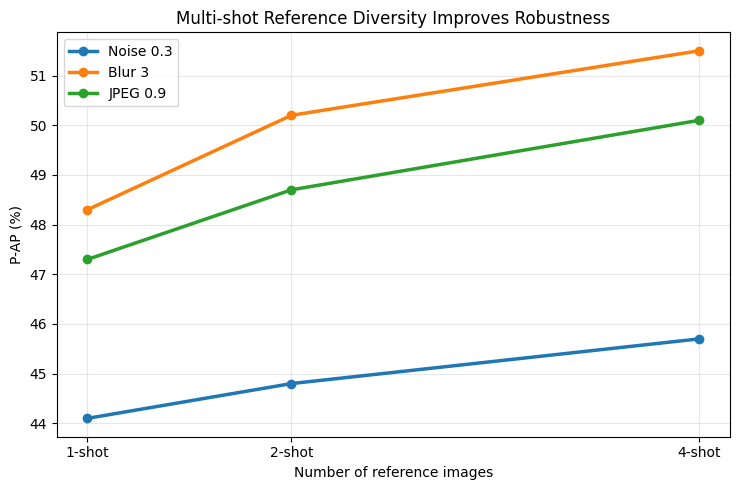

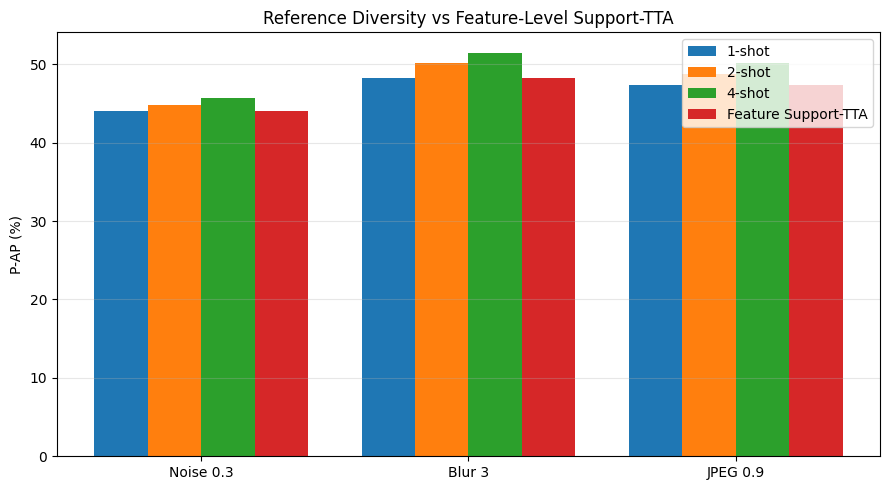

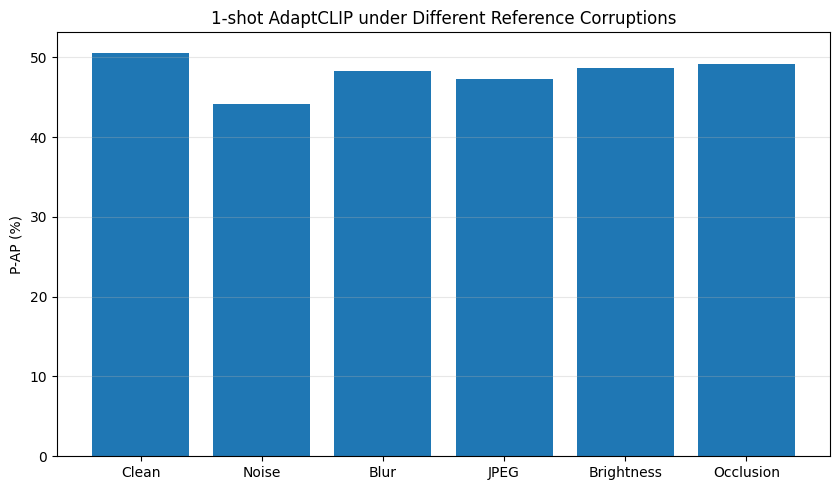

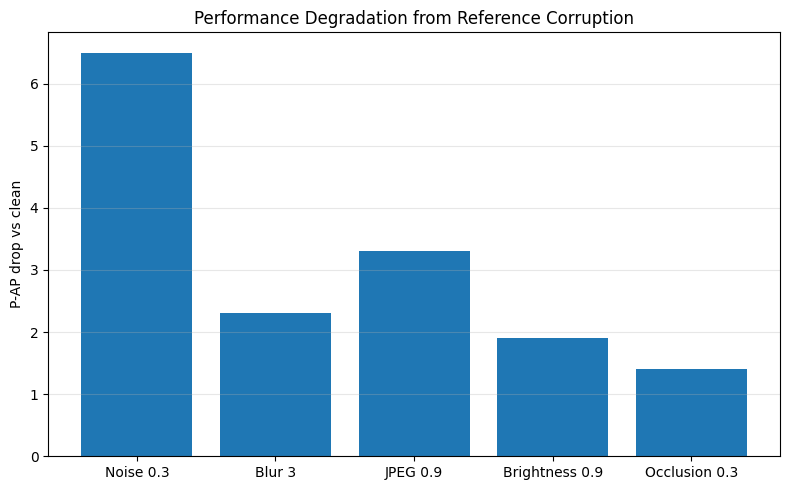

,Corruption,P-AP Drop
0,Noise 0.3,6.5
1,Blur 3,2.3
2,JPEG 0.9,3.3
3,Brightness 0.9,1.9
4,Occlusion 0.3,1.4


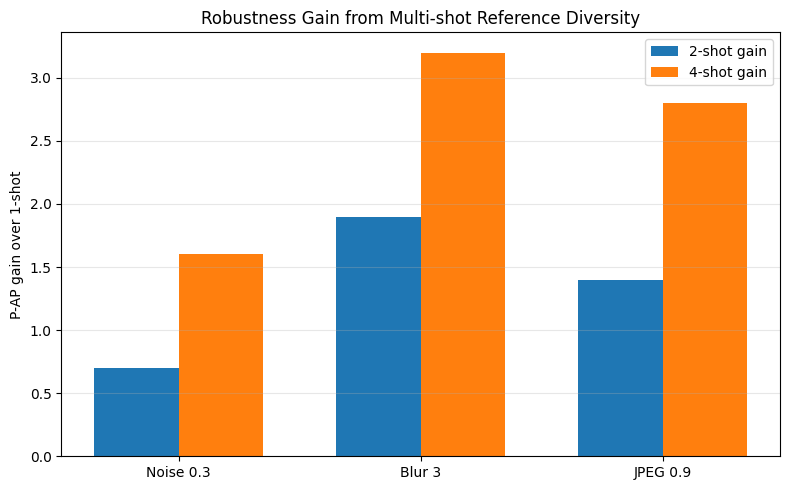

,Corruption,2-shot gain,4-shot gain
0,Noise 0.3,0.7,1.6
1,Blur 3,1.9,3.2
2,JPEG 0.9,1.4,2.8


Saved files:
- multishot_gain_results.csv
- reference_diversity_vs_tta.png
- pap_drop_results.csv
- multishot_gain_bar.png
- corruption_comparison_bar.png
- master_results_pap.csv
- pap_drop_bar.png
- multishot_line_plot.png
- corruption_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
# ============================================================
# FINAL PLOTS + TABLES FOR REPORT/PRESENTATION
# ============================================================

import os
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

OUT = "/content/adaptclip_final_outputs"
os.makedirs(OUT, exist_ok=True)

# -----------------------------
# 1) Master results table
# -----------------------------

master = pd.DataFrame({
    "Method": [
        "1-shot AdaptCLIP",
        "2-shot AdaptCLIP",
        "4-shot AdaptCLIP",
        "Feature Support-TTA"
    ],
    "Noise 0.3 P-AP": [44.1, 44.8, 45.7, 44.1],
    "Blur 3 P-AP": [48.3, 50.2, 51.5, 48.2],
    "JPEG 0.9 P-AP": [47.3, 48.7, 50.1, 47.4],
})

master.to_csv(f"{OUT}/master_results_pap.csv", index=False)
display(master)

# -----------------------------
# 2) Corruption summary table
# -----------------------------

corruption_summary = pd.DataFrame({
    "Condition": [
        "Clean 1-shot",
        "Noise 0.3",
        "Blur 3",
        "JPEG 0.9",
        "Brightness 0.9",
        "Occlusion 0.3"
    ],
    "I-AUROC": [94.3, 92.7, 93.2, 93.5, 94.2, 93.6],
    "P-AUROC": [94.0, 91.6, 93.2, 92.9, 93.2, 93.6],
    "P-AP": [50.6, 44.1, 48.3, 47.3, 48.7, 49.2]
})

corruption_summary["P-AP Drop vs Clean"] = 50.6 - corruption_summary["P-AP"]
corruption_summary.to_csv(f"{OUT}/corruption_summary.csv", index=False)
display(corruption_summary)

# -----------------------------
# 3) Line plot: multi-shot robustness
# -----------------------------

shots = [1, 2, 4]
noise = [44.1, 44.8, 45.7]
blur = [48.3, 50.2, 51.5]
jpeg = [47.3, 48.7, 50.1]

plt.figure(figsize=(7.5, 5))
plt.plot(shots, noise, marker="o", linewidth=2.5, label="Noise 0.3")
plt.plot(shots, blur, marker="o", linewidth=2.5, label="Blur 3")
plt.plot(shots, jpeg, marker="o", linewidth=2.5, label="JPEG 0.9")
plt.xticks(shots, ["1-shot", "2-shot", "4-shot"])
plt.xlabel("Number of reference images")
plt.ylabel("P-AP (%)")
plt.title("Multi-shot Reference Diversity Improves Robustness")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig(f"{OUT}/multishot_line_plot.png", dpi=400)
plt.show()

# -----------------------------
# 4) Grouped bar: 1-shot vs 2-shot vs 4-shot vs Feature-TTA
# -----------------------------

conditions = ["Noise 0.3", "Blur 3", "JPEG 0.9"]
one_shot = [44.1, 48.3, 47.3]
two_shot = [44.8, 50.2, 48.7]
four_shot = [45.7, 51.5, 50.1]
feature_tta = [44.1, 48.2, 47.4]

x = np.arange(len(conditions))
w = 0.2

plt.figure(figsize=(9, 5))
plt.bar(x - 1.5*w, one_shot, width=w, label="1-shot")
plt.bar(x - 0.5*w, two_shot, width=w, label="2-shot")
plt.bar(x + 0.5*w, four_shot, width=w, label="4-shot")
plt.bar(x + 1.5*w, feature_tta, width=w, label="Feature Support-TTA")

plt.xticks(x, conditions)
plt.ylabel("P-AP (%)")
plt.title("Reference Diversity vs Feature-Level Support-TTA")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/reference_diversity_vs_tta.png", dpi=400)
plt.show()

# -----------------------------
# 5) Corruption comparison: 1-shot severe/mild corruptions
# -----------------------------

conditions = ["Clean", "Noise", "Blur", "JPEG", "Brightness", "Occlusion"]
pap = [50.6, 44.1, 48.3, 47.3, 48.7, 49.2]

plt.figure(figsize=(8.5, 5))
plt.bar(conditions, pap)
plt.ylabel("P-AP (%)")
plt.title("1-shot AdaptCLIP under Different Reference Corruptions")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/corruption_comparison_bar.png", dpi=400)
plt.show()

# -----------------------------
# 6) Performance drop plot
# -----------------------------

drop_df = pd.DataFrame({
    "Corruption": ["Noise 0.3", "Blur 3", "JPEG 0.9", "Brightness 0.9", "Occlusion 0.3"],
    "P-AP Drop": [50.6 - 44.1, 50.6 - 48.3, 50.6 - 47.3, 50.6 - 48.7, 50.6 - 49.2]
})
drop_df.to_csv(f"{OUT}/pap_drop_results.csv", index=False)

plt.figure(figsize=(8, 5))
plt.bar(drop_df["Corruption"], drop_df["P-AP Drop"])
plt.ylabel("P-AP drop vs clean")
plt.title("Performance Degradation from Reference Corruption")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/pap_drop_bar.png", dpi=400)
plt.show()

display(drop_df)

# -----------------------------
# 7) Improvement plot: 2-shot and 4-shot gains over 1-shot
# -----------------------------

gain_df = pd.DataFrame({
    "Corruption": ["Noise 0.3", "Blur 3", "JPEG 0.9"],
    "2-shot gain": [44.8 - 44.1, 50.2 - 48.3, 48.7 - 47.3],
    "4-shot gain": [45.7 - 44.1, 51.5 - 48.3, 50.1 - 47.3],
})
gain_df.to_csv(f"{OUT}/multishot_gain_results.csv", index=False)

x = np.arange(len(gain_df))
w = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - w/2, gain_df["2-shot gain"], width=w, label="2-shot gain")
plt.bar(x + w/2, gain_df["4-shot gain"], width=w, label="4-shot gain")
plt.xticks(x, gain_df["Corruption"])
plt.ylabel("P-AP gain over 1-shot")
plt.title("Robustness Gain from Multi-shot Reference Diversity")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUT}/multishot_gain_bar.png", dpi=400)
plt.show()

display(gain_df)

# -----------------------------
# 8) Save all outputs as zip
# -----------------------------

zip_path = "/content/adaptclip_final_outputs.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for fname in os.listdir(OUT):
        z.write(os.path.join(OUT, fname), arcname=fname)

print("Saved files:")
for fname in os.listdir(OUT):
    print("-", fname)

files.download(zip_path)